In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [100]:
df = pd.read_csv("/content/HHS_Unaccompanied_Alien_Children_Program.csv")


In [101]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [102]:
print(df.columns.tolist())

['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care']


In [103]:
df = df.dropna(how="all")

print("Rows after removing blank rows:", len(df))

Rows after removing blank rows: 720


In [104]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[ns]


In [105]:
df = df.sort_values("Date")

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
719,2023-01-12,33.0,53.0,34.0,"6,566",436.0
718,2023-01-22,32.0,49.0,39.0,"7,122",227.0
717,2023-01-23,32.0,50.0,39.0,"7,280",181.0
716,2023-01-24,47.0,42.0,47.0,"7,433",175.0
715,2023-01-25,20.0,22.0,41.0,"7,538",180.0


In [106]:
numeric_columns = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

for column in numeric_columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

In [107]:
print(df.dtypes)

Date                                               datetime64[ns]
Children apprehended and placed in CBP custody*           float64
Children in CBP custody                                   float64
Children transferred out of CBP custody                   float64
Children in HHS Care                                      float64
Children discharged from HHS Care                         float64
dtype: object


In [108]:
print(df.isnull().sum())

Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64


In [109]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [110]:
print("Duplicate dates:", df["Date"].duplicated().sum())

Duplicate dates: 0


Exploratory Data Analysis (EDA)

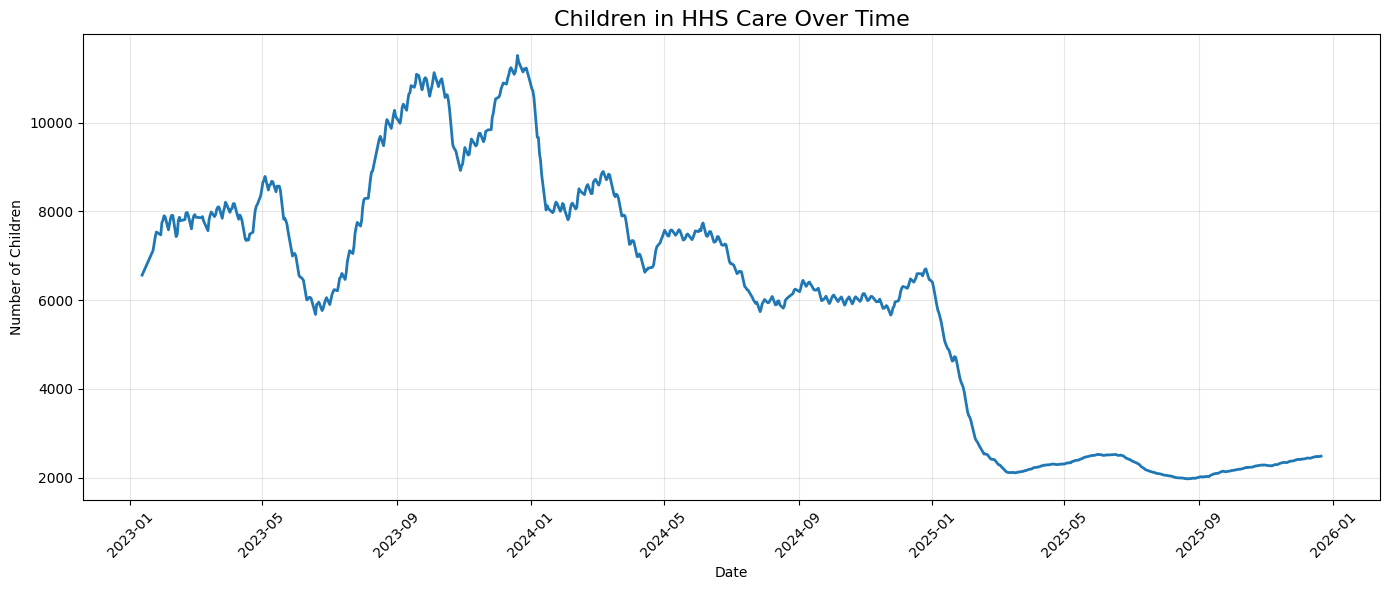

In [111]:
plt.figure(figsize=(14, 6))

# Ensure Date is datetime and values are numeric strings without commas
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Children in HHS Care'] = pd.to_numeric(df['Children in HHS Care'].astype(str).str.replace(',', ''), errors='coerce')

# Drop rows where data couldn't be converted to avoid plotting errors
plot_df = df.dropna(subset=['Date', 'Children in HHS Care']).sort_values('Date')

plt.plot(plot_df["Date"], plot_df["Children in HHS Care"], linewidth=2)

plt.title("Children in HHS Care Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Number of Children")

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

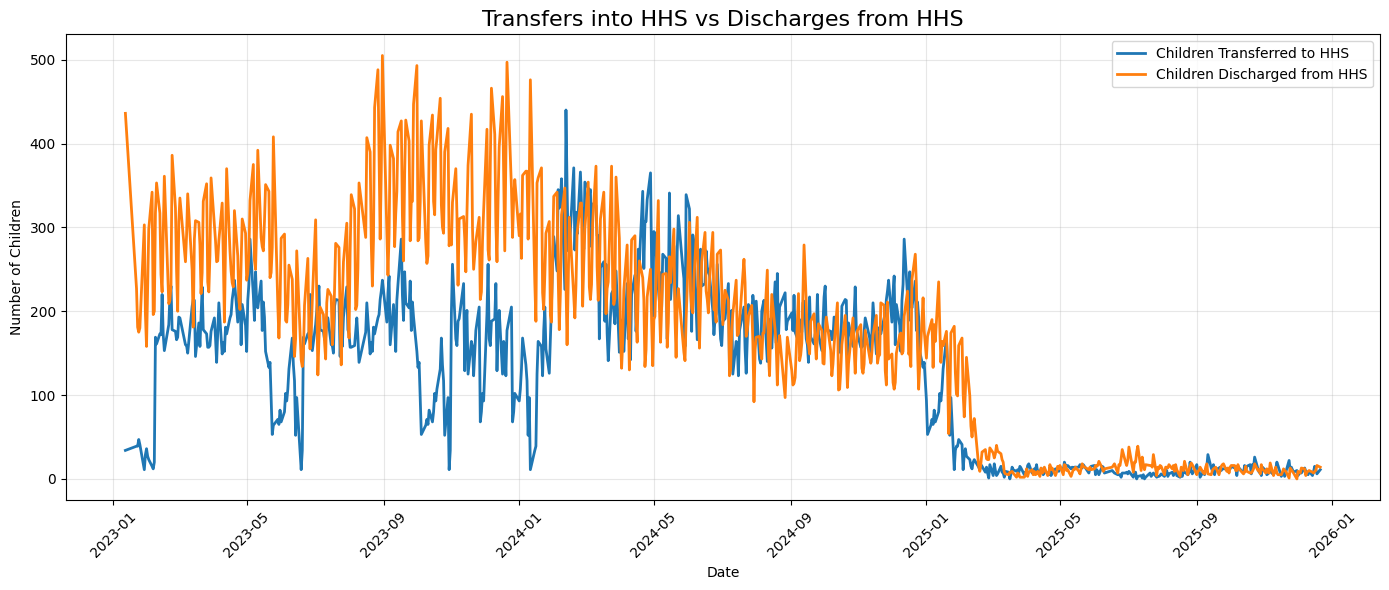

In [112]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Children transferred out of CBP custody"],
    label="Children Transferred to HHS",
    linewidth=2
)

plt.plot(
    df["Date"],
    df["Children discharged from HHS Care"],
    label="Children Discharged from HHS",
    linewidth=2
)

plt.title("Transfers into HHS vs Discharges from HHS", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Number of Children")

plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

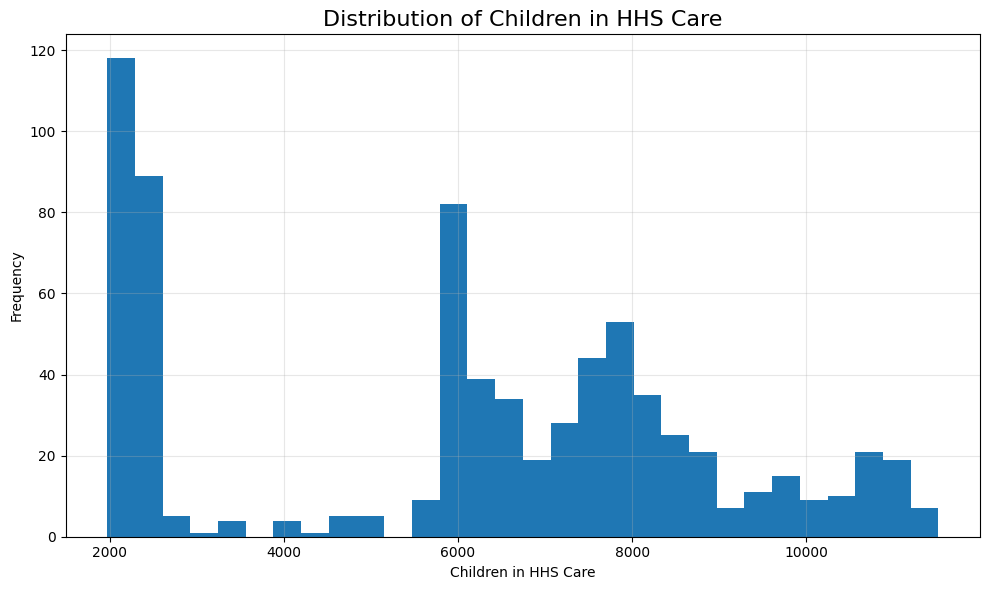

In [113]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Children in HHS Care"],
    bins=30
)

plt.title("Distribution of Children in HHS Care", fontsize=16)
plt.xlabel("Children in HHS Care")
plt.ylabel("Frequency")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [114]:
print(df.columns)


Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')


In [115]:
df["Month"] = df["Date"].dt.to_period("M")

In [116]:
monthly_hhs = (
    df.groupby("Month")["Children in HHS Care"]
    .mean()
)

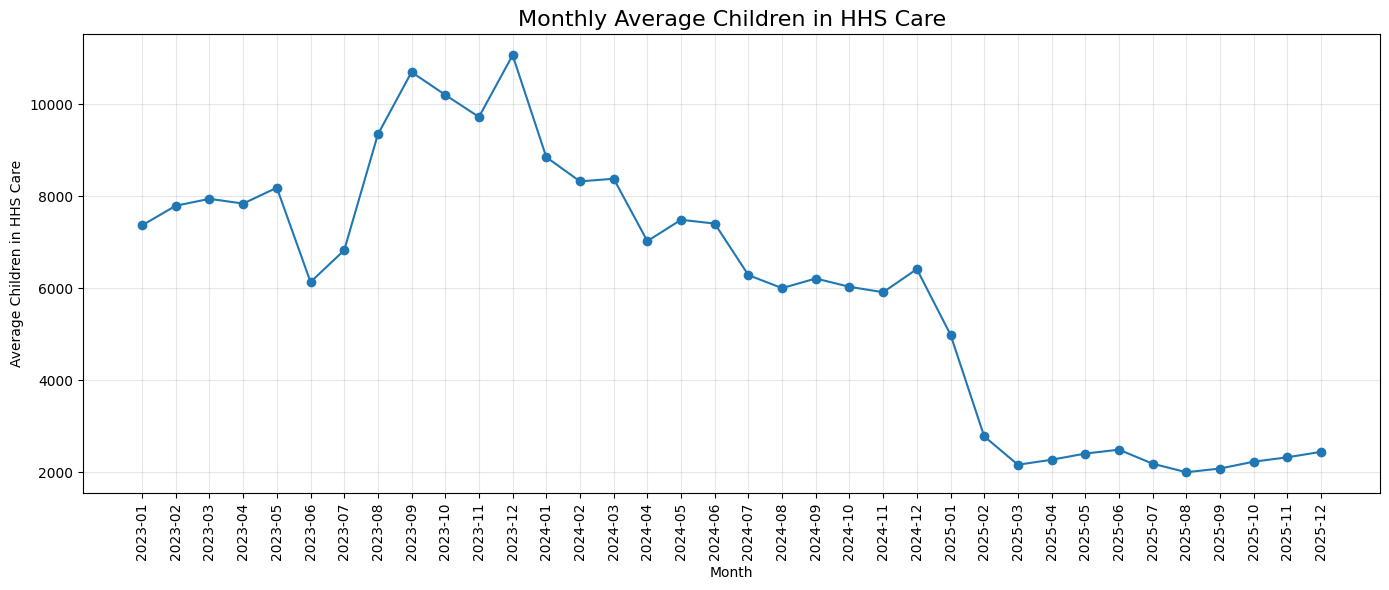

In [117]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_hhs.index.astype(str),
    monthly_hhs.values,
    marker="o"
)

plt.title("Monthly Average Children in HHS Care", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Average Children in HHS Care")

plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [118]:
df["Net_Pressure"] = (
    df["Children transferred out of CBP custody"]
    - df["Children discharged from HHS Care"]
)

In [119]:
df[
    [
        "Date",
        "Children transferred out of CBP custody",
        "Children discharged from HHS Care",
        "Net_Pressure"
    ]
].head(10)


,Date,Children transferred out of CBP custody,Children discharged from HHS Care,Net_Pressure
719,2023-01-12,34.0,436.0,-402.0
718,2023-01-22,39.0,227.0,-188.0
717,2023-01-23,39.0,181.0,-142.0
716,2023-01-24,47.0,175.0,-128.0
715,2023-01-25,41.0,180.0,-139.0
714,2023-01-29,11.0,303.0,-292.0
713,2023-01-30,29.0,196.0,-167.0
712,2023-01-31,36.0,158.0,-122.0
711,2023-02-01,27.0,231.0,-204.0
710,2023-02-02,23.0,298.0,-275.0


In [120]:
print(df.shape)
print(df.head())

(720, 8)
          Date  Children apprehended and placed in CBP custody*  \
719 2023-01-12                                             33.0   
718 2023-01-22                                             32.0   
717 2023-01-23                                             32.0   
716 2023-01-24                                             47.0   
715 2023-01-25                                             20.0   

     Children in CBP custody  Children transferred out of CBP custody  \
719                     53.0                                     34.0   
718                     49.0                                     39.0   
717                     50.0                                     39.0   
716                     42.0                                     47.0   
715                     22.0                                     41.0   

     Children in HHS Care  Children discharged from HHS Care    Month  \
719                6566.0                              436.0  2023-01   
718

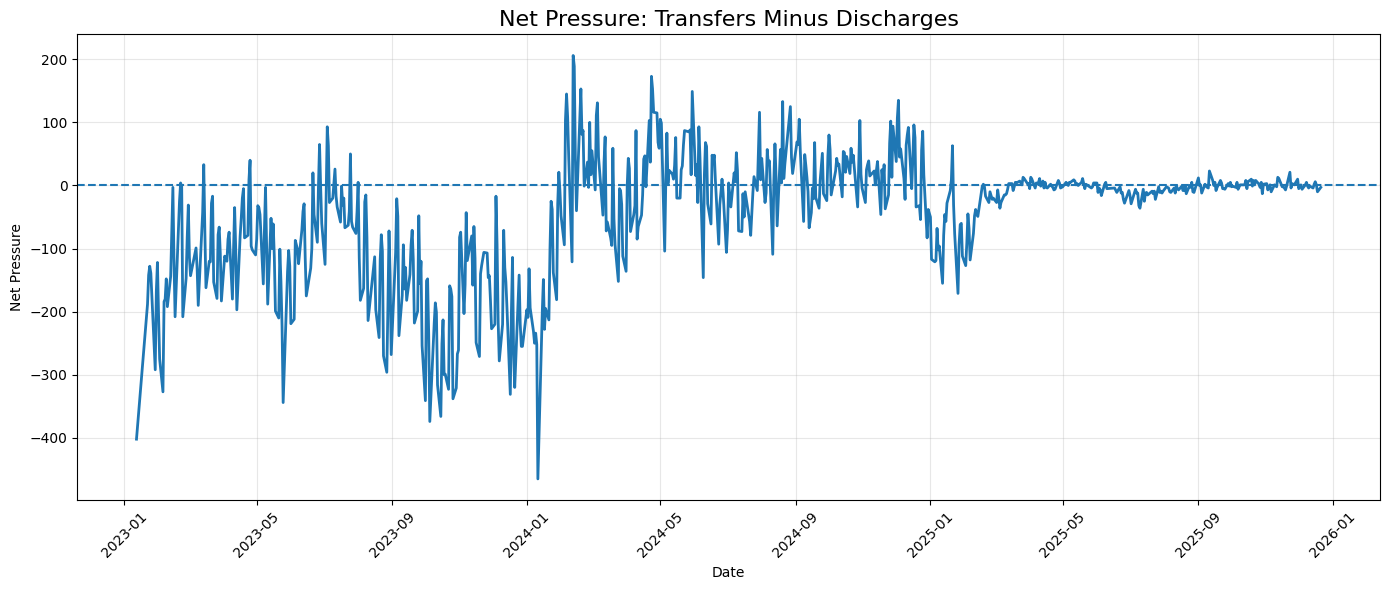

In [121]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Net_Pressure"],
    linewidth=2
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Net Pressure: Transfers Minus Discharges", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Net Pressure")

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [122]:
correlation = df[
    [
        "Children apprehended and placed in CBP custody*",
        "Children in CBP custody",
        "Children transferred out of CBP custody",
        "Children in HHS Care",
        "Children discharged from HHS Care",
        "Net_Pressure"
    ]
].corr()

print(correlation)

                                                 Children apprehended and placed in CBP custody*  \
Children apprehended and placed in CBP custody*                                         1.000000   
Children in CBP custody                                                                 0.950604   
Children transferred out of CBP custody                                                 0.887896   
Children in HHS Care                                                                    0.691312   
Children discharged from HHS Care                                                       0.627755   
Net_Pressure                                                                            0.078248   

                                                 Children in CBP custody  \
Children apprehended and placed in CBP custody*                 0.950604   
Children in CBP custody                                         1.000000   
Children transferred out of CBP custody                         0.92503

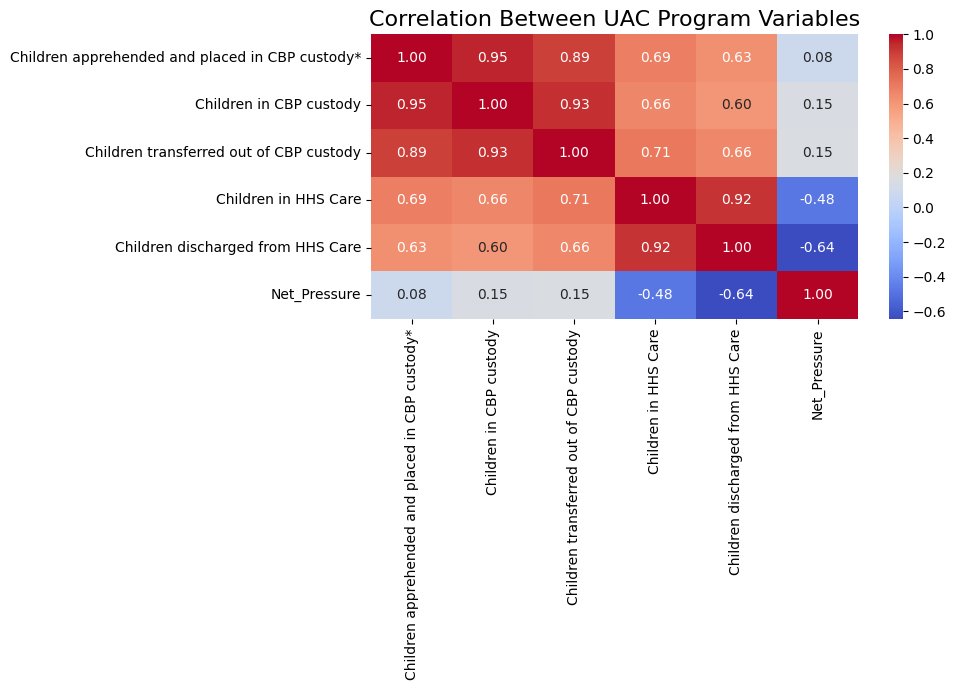

In [123]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between UAC Program Variables", fontsize=16)

plt.tight_layout()
plt.show()

In [124]:
summary = df[
    [
        "Children apprehended and placed in CBP custody*",
        "Children in CBP custody",
        "Children transferred out of CBP custody",
        "Children in HHS Care",
        "Children discharged from HHS Care",
        "Net_Pressure"
    ]
].describe().T

summary

,count,mean,std,min,25%,50%,75%,max
Children apprehended and placed in CBP custody*,720.0,93.523611,72.646625,0.0,12.00,99.0,147.25,333.0
Children in CBP custody,720.0,171.494444,126.354965,7.0,36.00,193.0,263.25,531.0
Children transferred out of CBP custody,720.0,128.668056,97.322012,0.0,14.00,157.0,199.25,440.0
Children in HHS Care,720.0,6061.275000,2833.070109,1972.0,2467.75,6406.5,8010.25,11516.0
Children discharged from HHS Care,720.0,173.406944,125.702841,0.0,19.75,181.0,267.00,505.0
Net_Pressure,720.0,-44.738889,95.863856,-465.0,-94.25,-11.5,5.25,206.0


In [125]:
max_row = df.loc[
    df["Children in HHS Care"].idxmax()
]

print(max_row)

Date                                               2023-12-20 00:00:00
Children apprehended and placed in CBP custody*                  136.0
Children in CBP custody                                          246.0
Children transferred out of CBP custody                          123.0
Children in HHS Care                                           11516.0
Children discharged from HHS Care                                390.0
Month                                                          2023-12
Net_Pressure                                                    -267.0
Name: 495, dtype: object


In [126]:
min_row = df.loc[
    df["Children in HHS Care"].idxmin()
]

print(min_row)

Date                                               2025-08-21 00:00:00
Children apprehended and placed in CBP custody*                    6.0
Children in CBP custody                                           49.0
Children transferred out of CBP custody                            8.0
Children in HHS Care                                            1972.0
Children discharged from HHS Care                                 21.0
Month                                                          2025-08
Net_Pressure                                                     -13.0
Name: 82, dtype: object


In [127]:
max_transfer = df.loc[
    df["Children transferred out of CBP custody"].idxmax()
]

print(max_transfer)

Date                                               2024-02-12 00:00:00
Children apprehended and placed in CBP custody*                  213.0
Children in CBP custody                                          430.0
Children transferred out of CBP custody                          440.0
Children in HHS Care                                            8092.0
Children discharged from HHS Care                                234.0
Month                                                          2024-02
Net_Pressure                                                     206.0
Name: 460, dtype: object


In [128]:
max_discharge = df.loc[
    df["Children discharged from HHS Care"].idxmax()
]

print(max_discharge)

Date                                               2023-08-31 00:00:00
Children apprehended and placed in CBP custody*                  113.0
Children in CBP custody                                          280.0
Children transferred out of CBP custody                          237.0
Children in HHS Care                                           10140.0
Children discharged from HHS Care                                505.0
Month                                                          2023-08
Net_Pressure                                                    -268.0
Name: 570, dtype: object


In [129]:
df = df.sort_values("Date").reset_index(drop=True)

print(df[["Date", "Children in HHS Care"]].head())
print(df[["Date", "Children in HHS Care"]].tail())

        Date  Children in HHS Care
0 2023-01-12                6566.0
1 2023-01-22                7122.0
2 2023-01-23                7280.0
3 2023-01-24                7433.0
4 2023-01-25                7538.0
          Date  Children in HHS Care
715 2025-12-15                2470.0
716 2025-12-16                2468.0
717 2025-12-17                2481.0
718 2025-12-18                2472.0
719 2025-12-21                2484.0


In [130]:
target = "Children in HHS Care"

df["lag_1"] = df[target].shift(1)
df["lag_7"] = df[target].shift(7)
df["lag_14"] = df[target].shift(14)

In [131]:
print(
    df[
        [
            "Date",
            target,
            "lag_1",
            "lag_7",
            "lag_14"
        ]
    ].head(20)
)

         Date  Children in HHS Care   lag_1   lag_7  lag_14
0  2023-01-12                6566.0     NaN     NaN     NaN
1  2023-01-22                7122.0  6566.0     NaN     NaN
2  2023-01-23                7280.0  7122.0     NaN     NaN
3  2023-01-24                7433.0  7280.0     NaN     NaN
4  2023-01-25                7538.0  7433.0     NaN     NaN
5  2023-01-29                7472.0  7538.0     NaN     NaN
6  2023-01-30                7743.0  7472.0     NaN     NaN
7  2023-01-31                7803.0  7743.0  6566.0     NaN
8  2023-02-01                7903.0  7803.0  7122.0     NaN
9  2023-02-02                7879.0  7903.0  7280.0     NaN
10 2023-02-05                7586.0  7879.0  7433.0     NaN
11 2023-02-06                7720.0  7586.0  7538.0     NaN
12 2023-02-07                7855.0  7720.0  7472.0     NaN
13 2023-02-08                7915.0  7855.0  7743.0     NaN
14 2023-02-09                7908.0  7915.0  7803.0  6566.0
15 2023-02-12                7434.0  790

In [132]:
df["rolling_7_mean"] = (
    df[target]
    .rolling(window=7)
    .mean()
)

In [133]:
df["rolling_14_mean"] = (
    df[target]
    .rolling(window=14)
    .mean()
)

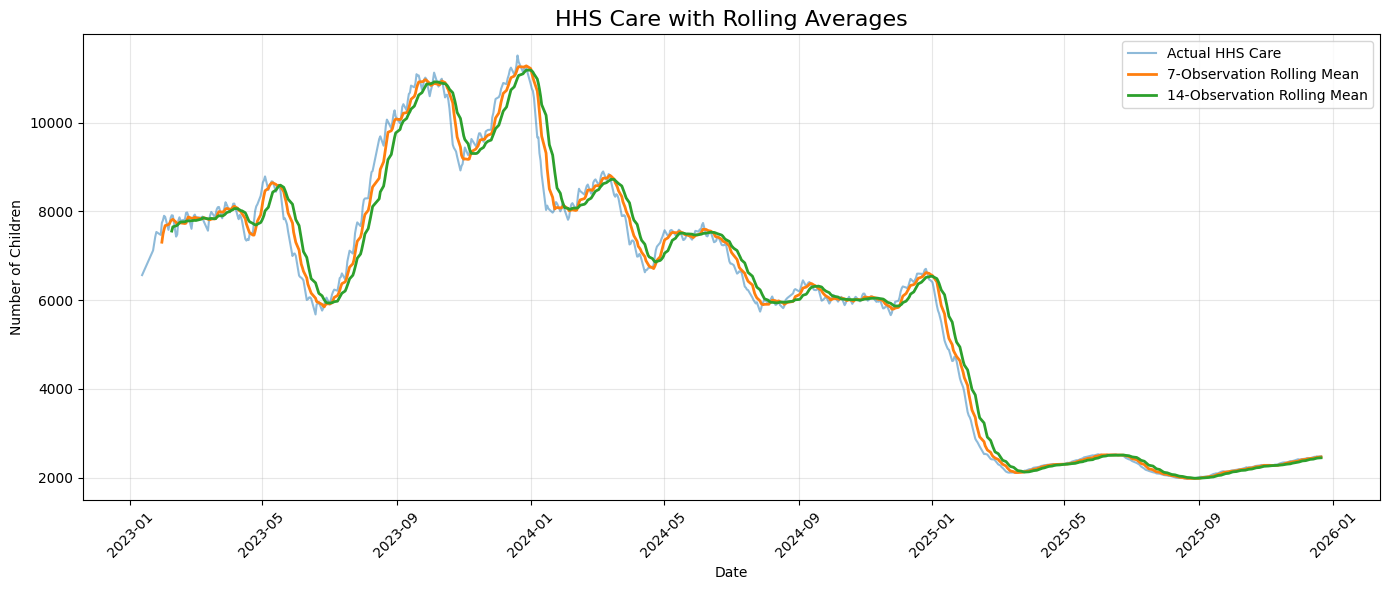

In [134]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df[target],
    label="Actual HHS Care",
    alpha=0.5
)

plt.plot(
    df["Date"],
    df["rolling_7_mean"],
    label="7-Observation Rolling Mean",
    linewidth=2
)

plt.plot(
    df["Date"],
    df["rolling_14_mean"],
    label="14-Observation Rolling Mean",
    linewidth=2
)

plt.title("HHS Care with Rolling Averages", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Number of Children")

plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [135]:
df["rolling_7_std"] = (
    df[target]
    .rolling(window=7)
    .std()
)

df["rolling_14_std"] = (
    df[target]
    .rolling(window=14)
    .std()
)

In [136]:
df["day_of_week"] = df["Date"].dt.dayofweek
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year

In [137]:
print(
    df[
        [
            "Date",
            "day_of_week",
            "month",
            "year"
        ]
    ].head(15)
)

         Date  day_of_week  month  year
0  2023-01-12            3      1  2023
1  2023-01-22            6      1  2023
2  2023-01-23            0      1  2023
3  2023-01-24            1      1  2023
4  2023-01-25            2      1  2023
5  2023-01-29            6      1  2023
6  2023-01-30            0      1  2023
7  2023-01-31            1      1  2023
8  2023-02-01            2      2  2023
9  2023-02-02            3      2  2023
10 2023-02-05            6      2  2023
11 2023-02-06            0      2  2023
12 2023-02-07            1      2  2023
13 2023-02-08            2      2  2023
14 2023-02-09            3      2  2023


In [138]:
df["day_name"] = df["Date"].dt.day_name()

In [139]:
print(
    df["day_name"].value_counts()
)

day_name
Tuesday      149
Thursday     147
Wednesday    147
Monday       145
Sunday       130
Friday         2
Name: count, dtype: int64


In [140]:
df["Net_Pressure"] = (
    df["Children transferred out of CBP custody"]
    - df["Children discharged from HHS Care"]
)

In [141]:
print(df.columns.tolist())

['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care', 'Month', 'Net_Pressure', 'lag_1', 'lag_7', 'lag_14', 'rolling_7_mean', 'rolling_14_mean', 'rolling_7_std', 'rolling_14_std', 'day_of_week', 'month', 'year', 'day_name']


In [142]:
print(
    df[
        [
            "lag_1",
            "lag_7",
            "lag_14",
            "rolling_7_mean",
            "rolling_14_mean",
            "rolling_7_std",
            "rolling_14_std"
        ]
    ].isnull().sum()
)

lag_1               1
lag_7               7
lag_14             14
rolling_7_mean      6
rolling_14_mean    13
rolling_7_std       6
rolling_14_std     13
dtype: int64


In [143]:
df_model = df.dropna().copy()

print("Original rows:", len(df))
print("Rows for modeling:", len(df_model))

Original rows: 720
Rows for modeling: 706


In [144]:
df["HHS_Care_Change"] = (
    df["Children in HHS Care"].diff()
)

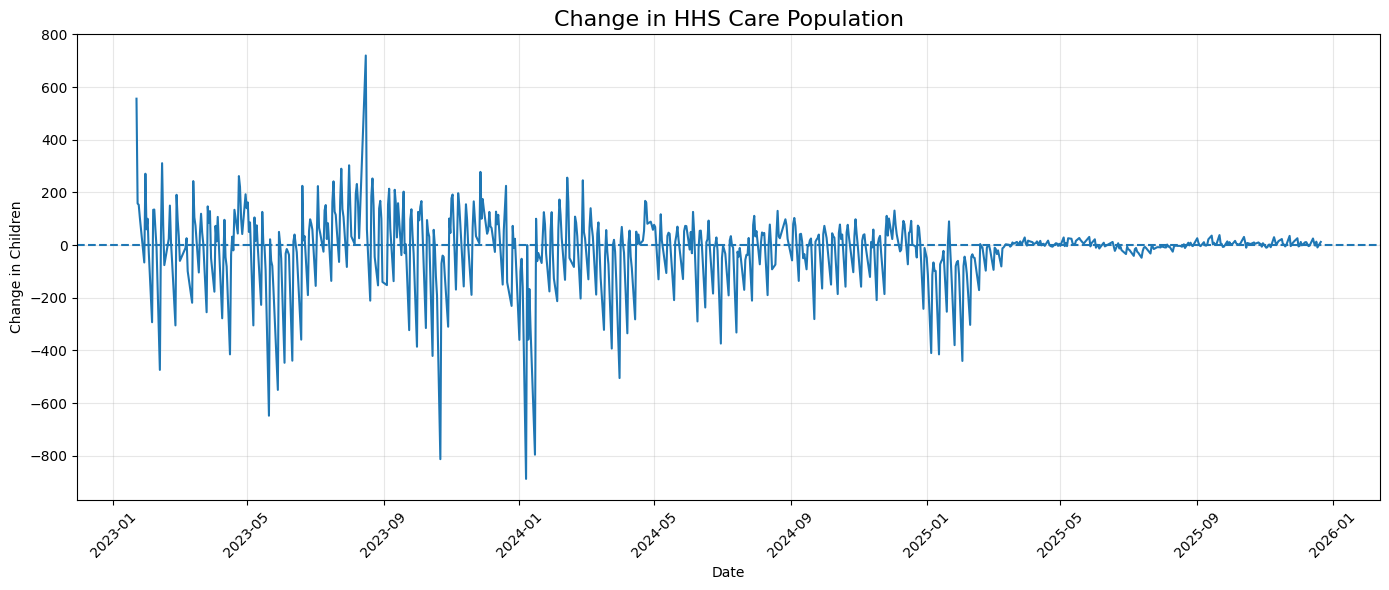

In [145]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["HHS_Care_Change"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Change in HHS Care Population", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Change in Children")

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [146]:
import os

# Create the directory if it doesn't exist
os.makedirs("../data", exist_ok=True)

df.to_csv(
    "../data/uac_cleaned_features.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [147]:
df_model = df.dropna().copy()

# Make sure data is sorted by date
df_model = df_model.sort_values("Date").reset_index(drop=True)

# Calculate split point
split_point = int(len(df_model) * 0.80)

# Training data
train = df_model.iloc[:split_point].copy()

# Testing data
test = df_model.iloc[split_point:].copy()

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 564
Testing observations: 142


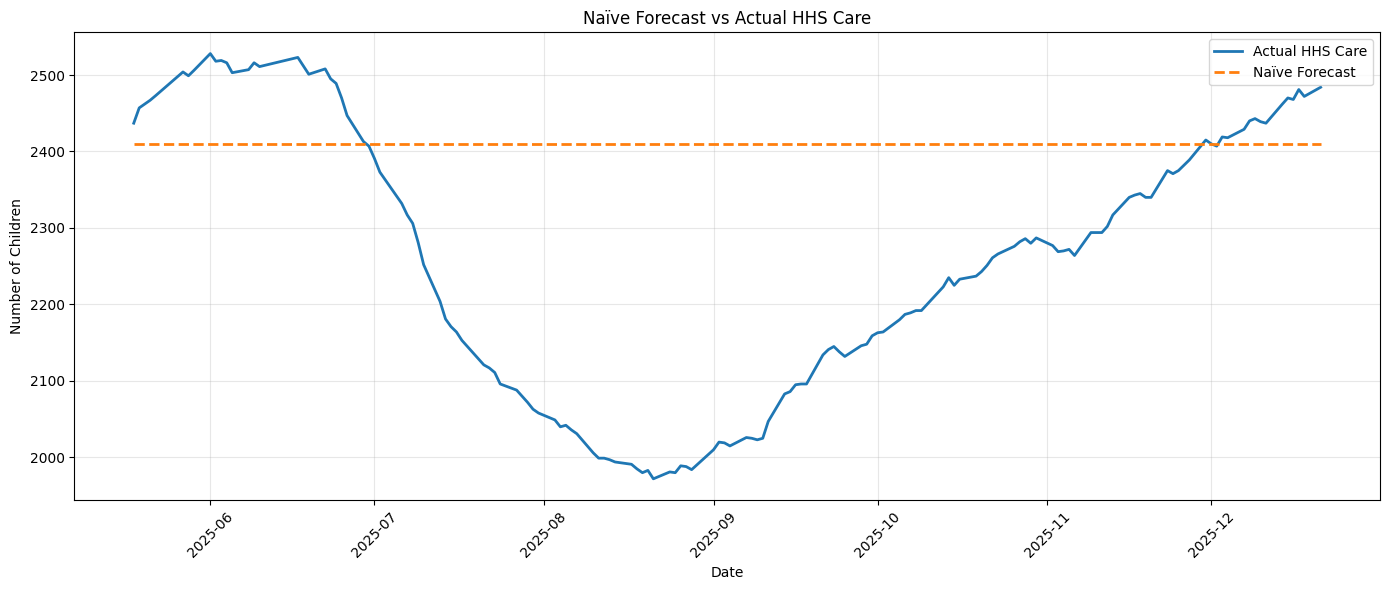

In [148]:
plt.figure(figsize=(14, 6))

# Recalculate Naive_Forecast to ensure it's available in the current 'test' DataFrame
last_train_value = train["Children in HHS Care"].iloc[-1]
test["Naive_Forecast"] = last_train_value

plt.plot(
    test["Date"],
    test["Children in HHS Care"],
    label="Actual HHS Care",
    linewidth=2
)

plt.plot(
    test["Date"],
    test["Naive_Forecast"],
    label="Naïve Forecast",
    linestyle="--",
    linewidth=2
)

plt.title("Naïve Forecast vs Actual HHS Care")
plt.xlabel("Date")
plt.ylabel("Number of Children")

plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [149]:
numeric_columns = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

for column in numeric_columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

print("Numeric columns converted successfully!")

Numeric columns converted successfully!


In [150]:
df = df.sort_values("Date").reset_index(drop=True)

df_model = df.dropna().copy()

split_point = int(len(df_model) * 0.80)

train = df_model.iloc[:split_point].copy()
test = df_model.iloc[split_point:].copy()

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 564
Testing observations: 142


In [151]:
last_train_value = train["Children in HHS Care"].iloc[-1]

test["Naive_Forecast"] = last_train_value

print("Last training value:", last_train_value)

print(
    test[
        [
            "Date",
            "Children in HHS Care",
            "Naive_Forecast"
        ]
    ].head(10)
)

Last training value: 2410.0
          Date  Children in HHS Care  Naive_Forecast
578 2025-05-18                2437.0          2410.0
579 2025-05-19                2457.0          2410.0
580 2025-05-21                2467.0          2410.0
581 2025-05-22                2473.0          2410.0
582 2025-05-27                2504.0          2410.0
583 2025-05-28                2499.0          2410.0
584 2025-05-29                2506.0          2410.0
585 2025-06-01                2528.0          2410.0
586 2025-06-02                2518.0          2410.0
587 2025-06-03                2519.0          2410.0


In [152]:
print(test["Children in HHS Care"].dtype)
print(test["Naive_Forecast"].dtype)

float64
float64


In [153]:
from sklearn.metrics import mean_absolute_error

mae_naive = mean_absolute_error(
    test["Children in HHS Care"],
    test["Naive_Forecast"]
)

print("Naïve Forecast MAE:", round(mae_naive, 2))

Naïve Forecast MAE: 196.09


In [154]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_naive = np.sqrt(
    mean_squared_error(
        test["Children in HHS Care"],
        test["Naive_Forecast"]
    )
)

print("Naïve Forecast RMSE:", round(rmse_naive, 2))

Naïve Forecast RMSE: 239.35


In [155]:
from sklearn.metrics import mean_absolute_percentage_error

mape_naive = mean_absolute_percentage_error(
    test["Children in HHS Care"],
    test["Naive_Forecast"]
) * 100

print("Naïve Forecast MAPE:", round(mape_naive, 2), "%")


Naïve Forecast MAPE: 9.24 %


In [156]:
# Take the last 7 observations from the training data
last_7_values = train["Children in HHS Care"].tail(7)

# Calculate their average
moving_average_value = last_7_values.mean()

print("Last 7 HHS Care values:")
print(last_7_values)

print("\nMoving Average Forecast:", round(moving_average_value, 2))

Last 7 HHS Care values:
571    2335.0
572    2361.0
573    2385.0
574    2392.0
575    2394.0
576    2394.0
577    2410.0
Name: Children in HHS Care, dtype: float64

Moving Average Forecast: 2381.57


In [157]:
test["Moving_Average_Forecast"] = moving_average_value

print(
    test[
        [
            "Date",
            "Children in HHS Care",
            "Moving_Average_Forecast"
        ]
    ].head(10)
)

          Date  Children in HHS Care  Moving_Average_Forecast
578 2025-05-18                2437.0              2381.571429
579 2025-05-19                2457.0              2381.571429
580 2025-05-21                2467.0              2381.571429
581 2025-05-22                2473.0              2381.571429
582 2025-05-27                2504.0              2381.571429
583 2025-05-28                2499.0              2381.571429
584 2025-05-29                2506.0              2381.571429
585 2025-06-01                2528.0              2381.571429
586 2025-06-02                2518.0              2381.571429
587 2025-06-03                2519.0              2381.571429


In [158]:
from sklearn.metrics import mean_absolute_error

mae_ma = mean_absolute_error(
    test["Children in HHS Care"],
    test["Moving_Average_Forecast"]
)

print("Moving Average MAE:", round(mae_ma, 2))

Moving Average MAE: 183.83


In [159]:
rmse_ma = np.sqrt(
    mean_squared_error(
        test["Children in HHS Care"],
        test["Moving_Average_Forecast"]
    )
)

print("Moving Average RMSE:", round(rmse_ma, 2))

Moving Average RMSE: 221.09


In [160]:
mape_ma = mean_absolute_percentage_error(
    test["Children in HHS Care"],
    test["Moving_Average_Forecast"]
) * 100

print("Moving Average MAPE:", round(mape_ma, 2), "%")

Moving Average MAPE: 8.62 %


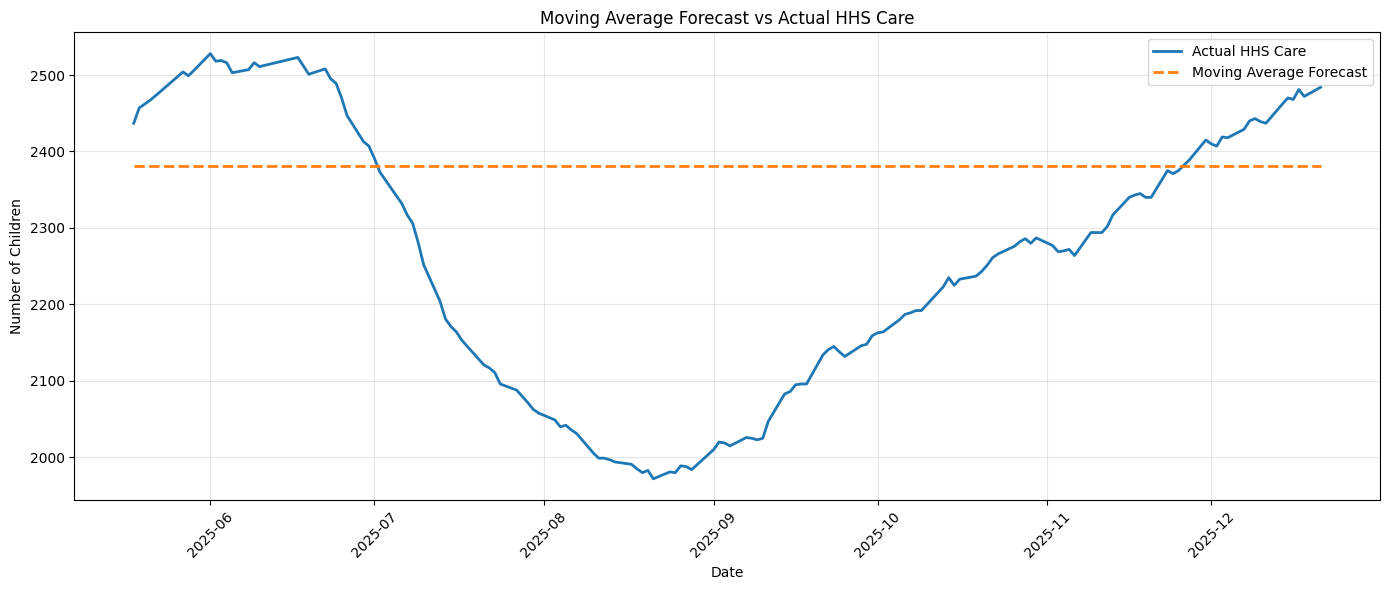

In [161]:
plt.figure(figsize=(14, 6))

plt.plot(
    test["Date"],
    test["Children in HHS Care"],
    label="Actual HHS Care",
    linewidth=2
)

plt.plot(
    test["Date"],
    test["Moving_Average_Forecast"],
    label="Moving Average Forecast",
    linestyle="--",
    linewidth=2
)

plt.title("Moving Average Forecast vs Actual HHS Care")
plt.xlabel("Date")
plt.ylabel("Number of Children")

plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [162]:
# Make sure the data is sorted
df = df.sort_values("Date").reset_index(drop=True)

# Remove rows with missing values created by lag/rolling features
df_model = df.dropna().copy()

# 80% training, 20% testing
split_point = int(len(df_model) * 0.80)

train = df_model.iloc[:split_point].copy()
test = df_model.iloc[split_point:].copy()

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 564
Testing observations: 142


In [163]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Ensure the 'Children in HHS Care' column in the train DataFrame is numeric
train["Children in HHS Care"] = pd.to_numeric(train["Children in HHS Care"].astype(str).str.replace(',', ''), errors='coerce')

# Set the Date column as index for the ExponentialSmoothing model
# and select the target variable
model_es = ExponentialSmoothing(
    train.set_index("Date")["Children in HHS Care"], # Set 'Date' as index here
    trend="add",
    seasonal=None
)

fit_es = model_es.fit()

print("Exponential Smoothing model fitted successfully!")

Exponential Smoothing model fitted successfully!


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


In [164]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Create a simple numeric index for the training data
train_es = train["Children in HHS Care"].reset_index(drop=True)

# Create and fit the model
model_es = ExponentialSmoothing(
    train_es,
    trend="add",
    seasonal=None
)

fit_es = model_es.fit()

print("Exponential Smoothing model fitted successfully!")

Exponential Smoothing model fitted successfully!


In [165]:
# Forecast the same number of observations as the test set
es_forecast = fit_es.forecast(len(test))

# Store predictions
test["Exponential_Smoothing_Forecast"] = es_forecast.values

print(
    test[
        ["Date", "Children in HHS Care",
         "Exponential_Smoothing_Forecast"]
    ].head(10)
)

          Date  Children in HHS Care  Exponential_Smoothing_Forecast
578 2025-05-18                2437.0                     2417.900629
579 2025-05-19                2457.0                     2425.801258
580 2025-05-21                2467.0                     2433.701887
581 2025-05-22                2473.0                     2441.602516
582 2025-05-27                2504.0                     2449.503145
583 2025-05-28                2499.0                     2457.403773
584 2025-05-29                2506.0                     2465.304402
585 2025-06-01                2528.0                     2473.205031
586 2025-06-02                2518.0                     2481.105660
587 2025-06-03                2519.0                     2489.006289


In [166]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# Ensure the 'Children in HHS Care' column in the test DataFrame is numeric
test["Children in HHS Care"] = pd.to_numeric(test["Children in HHS Care"].astype(str).str.replace(',', ''), errors='coerce')

mae_es = mean_absolute_error(
    test["Children in HHS Care"],
    test["Exponential_Smoothing_Forecast"]
)

rmse_es = np.sqrt(
    mean_squared_error(
        test["Children in HHS Care"],
        test["Exponential_Smoothing_Forecast"]
    )
)

mape_es = mean_absolute_percentage_error(
    test["Children in HHS Care"],
    test["Exponential_Smoothing_Forecast"]
) * 100

print("Exponential Smoothing MAE:", round(mae_es, 2))
print("Exponential Smoothing RMSE:", round(rmse_es, 2))
print("Exponential Smoothing MAPE:", round(mape_es, 2), "%")

Exponential Smoothing MAE: 732.52
Exponential Smoothing RMSE: 814.0
Exponential Smoothing MAPE: 33.33 %


In [167]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

# Get the target series and set 'Date' as index
endog_series = train.set_index("Date")["Children in HHS Care"]

# Ensure the DatetimeIndex has an explicit frequency by reindexing to a daily range
# and filling any missing values. This creates a continuous daily time series.
min_date = endog_series.index.min()
max_date = endog_series.index.max()
full_daily_range = pd.date_range(start=min_date, end=max_date, freq='D')

# Reindex to the full daily range, filling missing days with NaN
endog_series_daily = endog_series.reindex(full_daily_range)

# Fill NaNs using forward fill then backward fill to ensure no missing values remain
endog_series_daily = endog_series_daily.fillna(method='ffill').fillna(method='bfill')

arima_model = ARIMA(
    endog_series_daily,
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

print("ARIMA model fitted successfully!")

/tmp/ipykernel_91085/2881502768.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  endog_series_daily = endog_series_daily.fillna(method='ffill').fillna(method='bfill')


ARIMA model fitted successfully!


In [168]:
arima_forecast = arima_fit.forecast(steps=len(test))

test["ARIMA_Forecast"] = arima_forecast.values

print(test[
    ["Date", "Children in HHS Care", "ARIMA_Forecast"]
].head(10))

          Date  Children in HHS Care  ARIMA_Forecast
578 2025-05-18                2437.0     2411.583056
579 2025-05-19                2457.0     2411.535658
580 2025-05-21                2467.0     2411.537077
581 2025-05-22                2473.0     2411.537035
582 2025-05-27                2504.0     2411.537036
583 2025-05-28                2499.0     2411.537036
584 2025-05-29                2506.0     2411.537036
585 2025-06-01                2528.0     2411.537036
586 2025-06-02                2518.0     2411.537036
587 2025-06-03                2519.0     2411.537036


In [169]:
mae_arima = mean_absolute_error(
    test["Children in HHS Care"],
    test["ARIMA_Forecast"]
)

rmse_arima = np.sqrt(
    mean_squared_error(
        test["Children in HHS Care"],
        test["ARIMA_Forecast"]
    )
)

mape_arima = mean_absolute_percentage_error(
    test["Children in HHS Care"],
    test["ARIMA_Forecast"]
) * 100

print("ARIMA MAE:", round(mae_arima, 2))
print("ARIMA RMSE:", round(rmse_arima, 2))
print("ARIMA MAPE:", round(mape_arima, 2), "%")

ARIMA MAE: 196.83
ARIMA RMSE: 240.4
ARIMA MAPE: 9.27 %


In [170]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# --- Naïve Forecast Metrics ---
last_train_value = train["Children in HHS Care"].iloc[-1]
test["Naive_Forecast"] = last_train_value

mae_naive = mean_absolute_error(
    test["Children in HHS Care"],
    test["Naive_Forecast"]
)

rmse_naive = np.sqrt(
    mean_squared_error(
        test["Children in HHS Care"],
        test["Naive_Forecast"]
    )
)

mape_naive = mean_absolute_percentage_error(
    test["Children in HHS Care"],
    test["Naive_Forecast"]
) * 100

# --- Moving Average Forecast Metrics ---
last_7_values = train["Children in HHS Care"].tail(7)
moving_average_value = last_7_values.mean()
test["Moving_Average_Forecast"] = moving_average_value

mae_ma = mean_absolute_error(
    test["Children in HHS Care"],
    test["Moving_Average_Forecast"]
)

rmse_ma = np.sqrt(
    mean_squared_error(
        test["Children in HHS Care"],
        test["Moving_Average_Forecast"]
    )
)

mape_ma = mean_absolute_percentage_error(
    test["Children in HHS Care"],
    test["Moving_Average_Forecast"]
) * 100

results = pd.DataFrame({
    "Model": [
        "Naïve Forecast",
        "Moving Average",
        "Exponential Smoothing",
        "ARIMA"
    ],
    "MAE": [
        mae_naive,
        mae_ma,
        mae_es,
        mae_arima
    ],
    "RMSE": [
        rmse_naive,
        rmse_ma,
        rmse_es,
        rmse_arima
    ],
    "MAPE": [
        mape_naive,
        mape_ma,
        mape_es,
        mape_arima
    ]
})

results.round(2)

,Model,MAE,RMSE,MAPE
0,Naïve Forecast,196.09,239.35,9.24
1,Moving Average,183.83,221.09,8.62
2,Exponential Smoothing,732.52,814.00,33.33
3,ARIMA,196.83,240.40,9.27


In [171]:
# Create a copy
ml_df = df.copy()

target = "Children in HHS Care"

# Ensure the target column is numeric in ml_df
ml_df[target] = pd.to_numeric(ml_df[target].astype(str).str.replace(',', ''), errors='coerce')

# Convert 'Date' column to datetime type in ml_df
ml_df['Date'] = pd.to_datetime(ml_df['Date'])

# Lag features
ml_df["lag_1"] = ml_df[target].shift(1)
ml_df["lag_7"] = ml_df[target].shift(7)
ml_df["lag_14"] = ml_df[target].shift(14)

# Rolling features based ONLY on previous observations
ml_df["rolling_7_mean"] = (
    ml_df[target].shift(1).rolling(7).mean()
)

ml_df["rolling_14_mean"] = (
    ml_df[target].shift(1).rolling(14).mean()
)

ml_df["rolling_7_std"] = (
    ml_df[target].shift(1).rolling(7).std()
)

ml_df["rolling_14_std"] = (
    ml_df[target].shift(1).rolling(14).std()
)

# Calendar features
ml_df["day_of_week"] = ml_df["Date"].dt.dayofweek
ml_df["month"] = ml_df["Date"].dt.month
ml_df["year"] = ml_df["Date"].dt.year

# Remove rows with missing feature values
ml_df = ml_df.dropna().reset_index(drop=True)

print("ML dataset shape:", ml_df.shape)

ML dataset shape: (706, 20)


In [172]:
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_7_mean",
    "rolling_14_mean",
    "rolling_7_std",
    "rolling_14_std",
    "day_of_week",
    "month",
    "year"
]

X = ml_df[features]
y = ml_df[target]

# Time-based 80/20 split
split_point_ml = int(len(ml_df) * 0.80)

X_train = X.iloc[:split_point_ml]
X_test = X.iloc[split_point_ml:]

y_train = y.iloc[:split_point_ml]
y_test = y.iloc[split_point_ml:]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 564
Testing observations: 142


In [173]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_forecast = rf_model.predict(X_test)

print("Random Forest model completed!")

Random Forest model completed!


In [174]:
mae_rf = mean_absolute_error(y_test, rf_forecast)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, rf_forecast)
)

mape_rf = mean_absolute_percentage_error(
    y_test,
    rf_forecast
) * 100

print("Random Forest MAE:", round(mae_rf, 2))
print("Random Forest RMSE:", round(rmse_rf, 2))
print("Random Forest MAPE:", round(mape_rf, 2), "%")

Random Forest MAE: 64.85
Random Forest RMSE: 86.72
Random Forest MAPE: 3.0 %


In [175]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_forecast = gb_model.predict(X_test)

print("Gradient Boosting model completed!")

Gradient Boosting model completed!


In [176]:
mae_gb = mean_absolute_error(y_test, gb_forecast)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, gb_forecast)
)

mape_gb = mean_absolute_percentage_error(
    y_test,
    gb_forecast
) * 100

print("Gradient Boosting MAE:", round(mae_gb, 2))
print("Gradient Boosting RMSE:", round(rmse_gb, 2))
print("Gradient Boosting MAPE:", round(mape_gb, 2), "%")

Gradient Boosting MAE: 64.33
Gradient Boosting RMSE: 85.04
Gradient Boosting MAPE: 2.98 %


In [177]:
final_results = pd.DataFrame({
    "Model": [
        "Naïve Forecast",
        "Moving Average",
        "Exponential Smoothing",
        "ARIMA",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        mae_naive,
        mae_ma,
        mae_es,
        mae_arima,
        mae_rf,
        mae_gb
    ],

    "RMSE": [
        rmse_naive,
        rmse_ma,
        rmse_es,
        rmse_arima,
        rmse_rf,
        rmse_gb
    ],

    "MAPE": [
        mape_naive,
        mape_ma,
        mape_es,
        mape_arima,
        mape_rf,
        mape_gb
    ]
})

final_results = final_results.round(2)

final_results

,Model,MAE,RMSE,MAPE
0,Naïve Forecast,196.09,239.35,9.24
1,Moving Average,183.83,221.09,8.62
2,Exponential Smoothing,732.52,814.00,33.33
3,ARIMA,196.83,240.40,9.27
4,Random Forest,64.85,86.72,3.00
5,Gradient Boosting,64.33,85.04,2.98


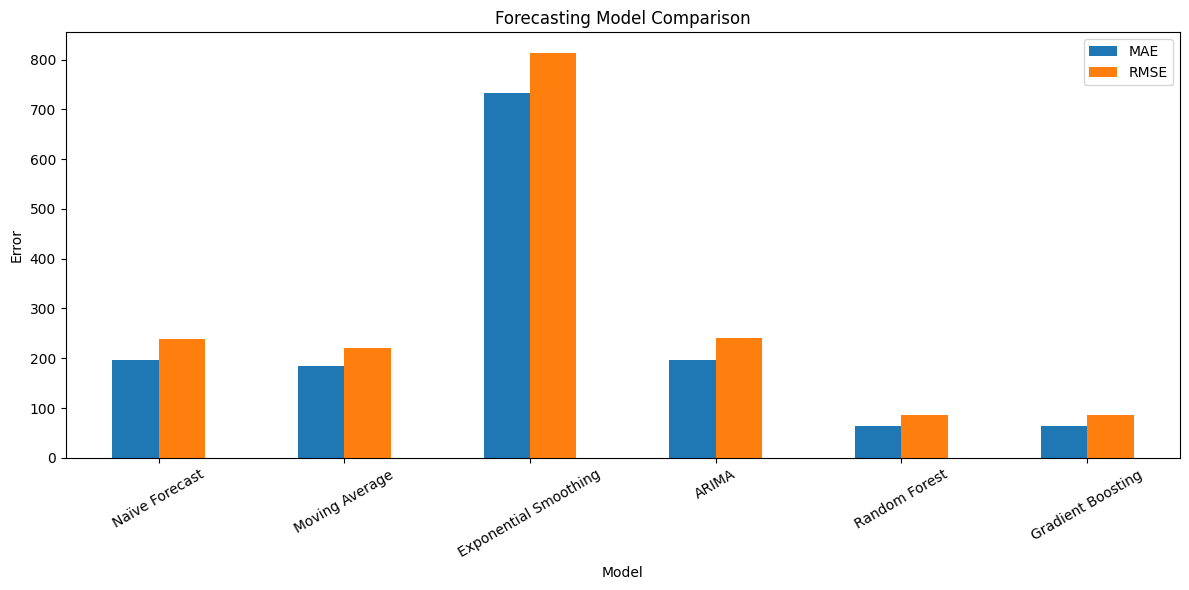

In [178]:
final_results.plot(
    x="Model",
    y=["MAE", "RMSE"],
    kind="bar",
    figsize=(12, 6)
)

plt.title("Forecasting Model Comparison")
plt.xlabel("Model")
plt.ylabel("Error")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

In [179]:
final_results = pd.DataFrame({
    "Model": [
        "Naïve Forecast",
        "Moving Average",
        "Exponential Smoothing",
        "ARIMA",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        mae_naive,
        mae_ma,
        mae_es,
        mae_arima,
        mae_rf,
        mae_gb
    ],

    "RMSE": [
        rmse_naive,
        rmse_ma,
        rmse_es,
        rmse_arima,
        rmse_rf,
        rmse_gb
    ],

    "MAPE": [
        mape_naive,
        mape_ma,
        mape_es,
        mape_arima,
        mape_rf,
        mape_gb
    ]
})

final_results = final_results.round(2)

print(final_results)

                   Model     MAE    RMSE   MAPE
0         Naïve Forecast  196.09  239.35   9.24
1         Moving Average  183.83  221.09   8.62
2  Exponential Smoothing  732.52  814.00  33.33
3                  ARIMA  196.83  240.40   9.27
4          Random Forest   64.85   86.72   3.00
5      Gradient Boosting   64.33   85.04   2.98


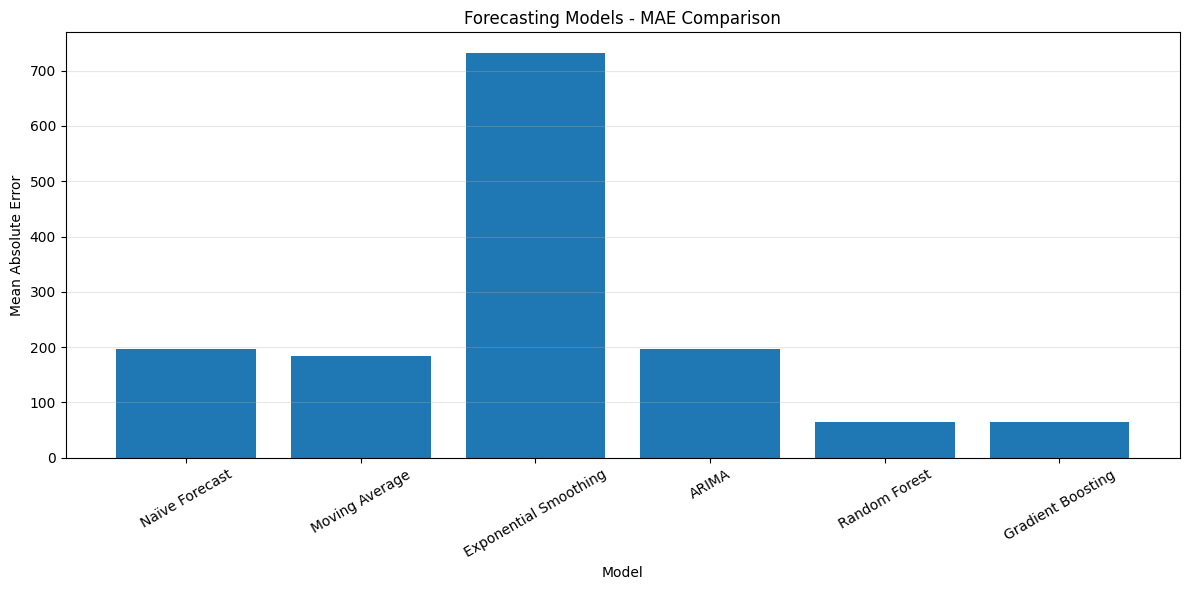

In [180]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_results["Model"],
    final_results["MAE"]
)

plt.title("Forecasting Models - MAE Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

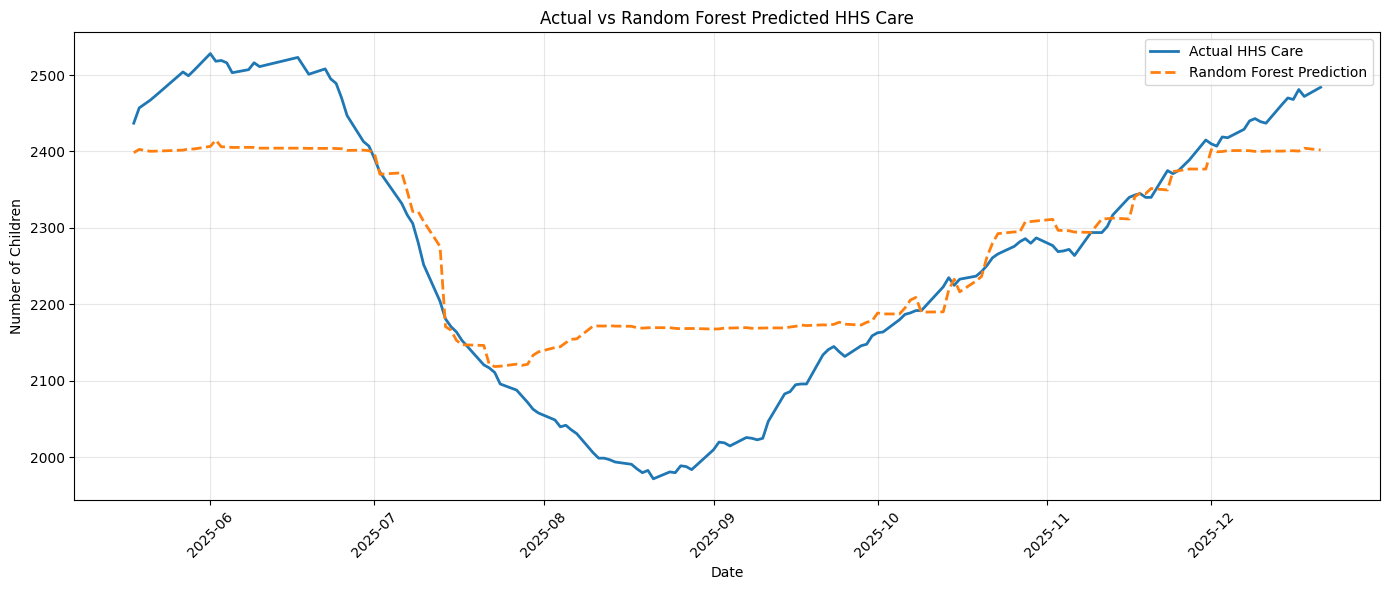

In [181]:
plt.figure(figsize=(14, 6))

plt.plot(
    ml_df["Date"].iloc[split_point_ml:],
    y_test.values,
    label="Actual HHS Care",
    linewidth=2
)

plt.plot(
    ml_df["Date"].iloc[split_point_ml:],
    rf_forecast,
    label="Random Forest Prediction",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Random Forest Predicted HHS Care")
plt.xlabel("Date")
plt.ylabel("Number of Children")

plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [182]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

           Feature  Importance
0            lag_1    0.836684
3   rolling_7_mean    0.103030
1            lag_7    0.028134
4  rolling_14_mean    0.022910
2           lag_14    0.006394
8            month    0.001121
7      day_of_week    0.000609
6   rolling_14_std    0.000539
5    rolling_7_std    0.000504
9             year    0.000075


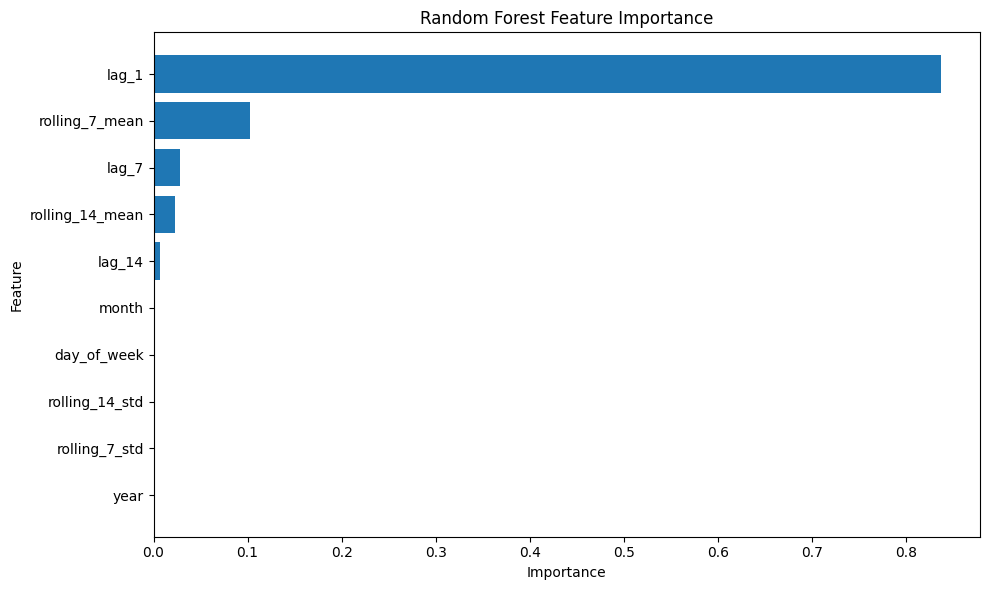

In [183]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [184]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_forecast = rf_model.predict(X_test)

print("Random Forest model recreated successfully!")

Random Forest model recreated successfully!


In [185]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

           Feature  Importance
0            lag_1    0.836684
3   rolling_7_mean    0.103030
1            lag_7    0.028134
4  rolling_14_mean    0.022910
2           lag_14    0.006394
8            month    0.001121
7      day_of_week    0.000609
6   rolling_14_std    0.000539
5    rolling_7_std    0.000504
9             year    0.000075


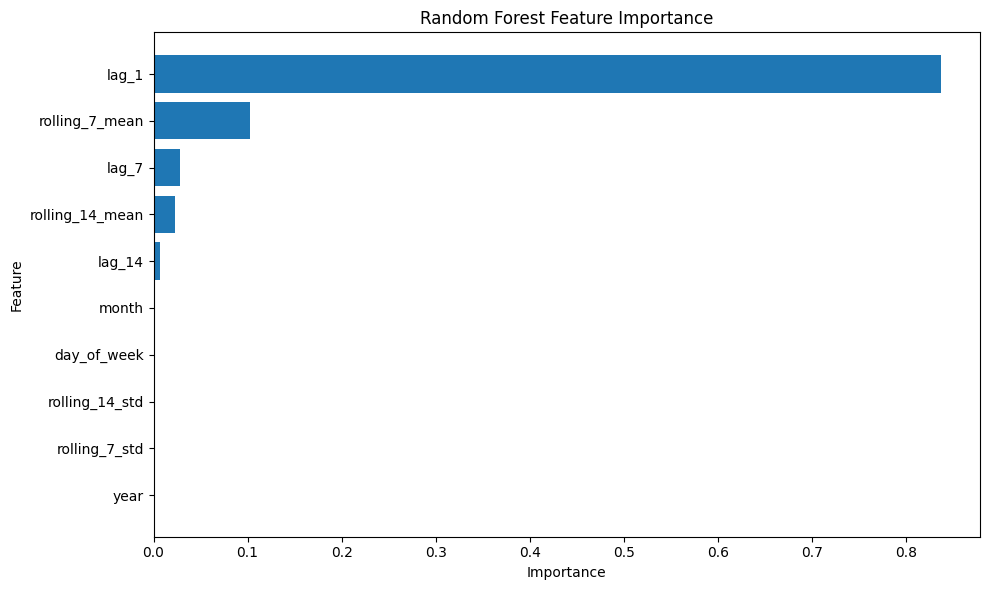

In [186]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [187]:
# ==========================================
# RECREATE ML DATA + TRAIN/TEST SPLIT
# ==========================================

# Make sure Date is in datetime format
df["Date"] = pd.to_datetime(df["Date"])

target = "Children in HHS Care"

# Create a fresh ML dataset
ml_df = df.copy()

# Lag features
ml_df["lag_1"] = ml_df[target].shift(1)
ml_df["lag_7"] = ml_df[target].shift(7)
ml_df["lag_14"] = ml_df[target].shift(14)

# Rolling features using ONLY previous observations
ml_df["rolling_7_mean"] = (
    ml_df[target].shift(1).rolling(7).mean()
)

ml_df["rolling_14_mean"] = (
    ml_df[target].shift(1).rolling(14).mean()
)

ml_df["rolling_7_std"] = (
    ml_df[target].shift(1).rolling(7).std()
)

ml_df["rolling_14_std"] = (
    ml_df[target].shift(1).rolling(14).std()
)

# Calendar features
ml_df["day_of_week"] = ml_df["Date"].dt.dayofweek
ml_df["month"] = ml_df["Date"].dt.month
ml_df["year"] = ml_df["Date"].dt.year

# Remove rows with missing values
ml_df = ml_df.dropna().reset_index(drop=True)

# Features used by Random Forest
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_7_mean",
    "rolling_14_mean",
    "rolling_7_std",
    "rolling_14_std",
    "day_of_week",
    "month",
    "year"
]

X = ml_df[features]
y = ml_df[target]

# Time-based 80/20 split
split_point_ml = int(len(ml_df) * 0.80)

X_train = X.iloc[:split_point_ml]
X_test = X.iloc[split_point_ml:]

y_train = y.iloc[:split_point_ml]
y_test = y.iloc[split_point_ml:]

print("ML dataset created successfully!")
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

ML dataset created successfully!
Training observations: 564
Testing observations: 142


In [188]:
# ==========================================
# RANDOM FOREST MODEL
# ==========================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_forecast = rf_model.predict(X_test)

print("Random Forest model recreated successfully!")

Random Forest model recreated successfully!


In [189]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

           Feature  Importance
0            lag_1    0.836684
3   rolling_7_mean    0.103030
1            lag_7    0.028134
4  rolling_14_mean    0.022910
2           lag_14    0.006394
8            month    0.001121
7      day_of_week    0.000609
6   rolling_14_std    0.000539
5    rolling_7_std    0.000504
9             year    0.000075


In [190]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Create a simple numeric index for the training data
train_es = train["Children in HHS Care"].reset_index(drop=True)

# Create and fit the model
model_es = ExponentialSmoothing(
    train_es,
    trend="add",
    seasonal=None
)

fit_es = model_es.fit()

print("Exponential Smoothing model fitted successfully!")

Exponential Smoothing model fitted successfully!


In [191]:
# Forecast the same number of observations as the test set
es_forecast = fit_es.forecast(len(test))

# Store predictions
test["Exponential_Smoothing_Forecast"] = es_forecast.values

print(
    test[
        ["Date", "Children in HHS Care",
         "Exponential_Smoothing_Forecast"]
    ].head(10)
)

          Date  Children in HHS Care  Exponential_Smoothing_Forecast
578 2025-05-18                2437.0                     2417.900629
579 2025-05-19                2457.0                     2425.801258
580 2025-05-21                2467.0                     2433.701887
581 2025-05-22                2473.0                     2441.602516
582 2025-05-27                2504.0                     2449.503145
583 2025-05-28                2499.0                     2457.403773
584 2025-05-29                2506.0                     2465.304402
585 2025-06-01                2528.0                     2473.205031
586 2025-06-02                2518.0                     2481.105660
587 2025-06-03                2519.0                     2489.006289


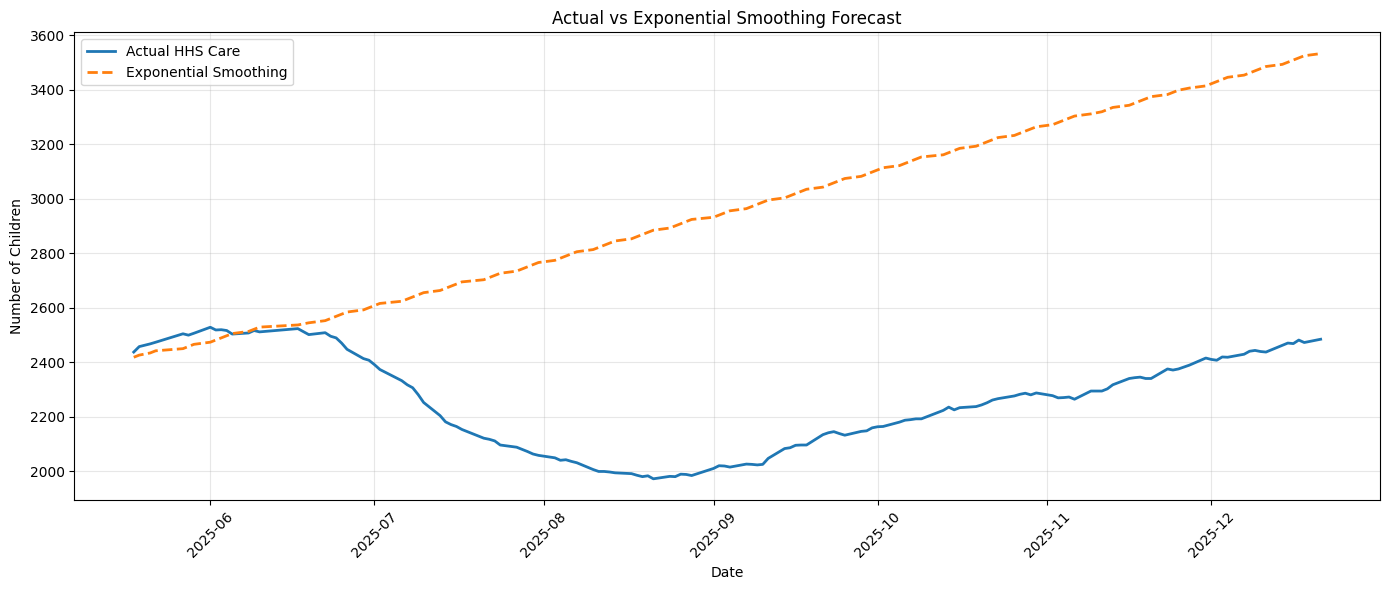

In [192]:
plt.figure(figsize=(14, 6))

plt.plot(
    test["Date"],
    test["Children in HHS Care"],
    label="Actual HHS Care",
    linewidth=2
)

plt.plot(
    test["Date"],
    test["Exponential_Smoothing_Forecast"],
    label="Exponential Smoothing",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Exponential Smoothing Forecast")
plt.xlabel("Date")
plt.ylabel("Number of Children")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [193]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_forecast = rf_model.predict(X_test)

print("Random Forest ready!")

Random Forest ready!


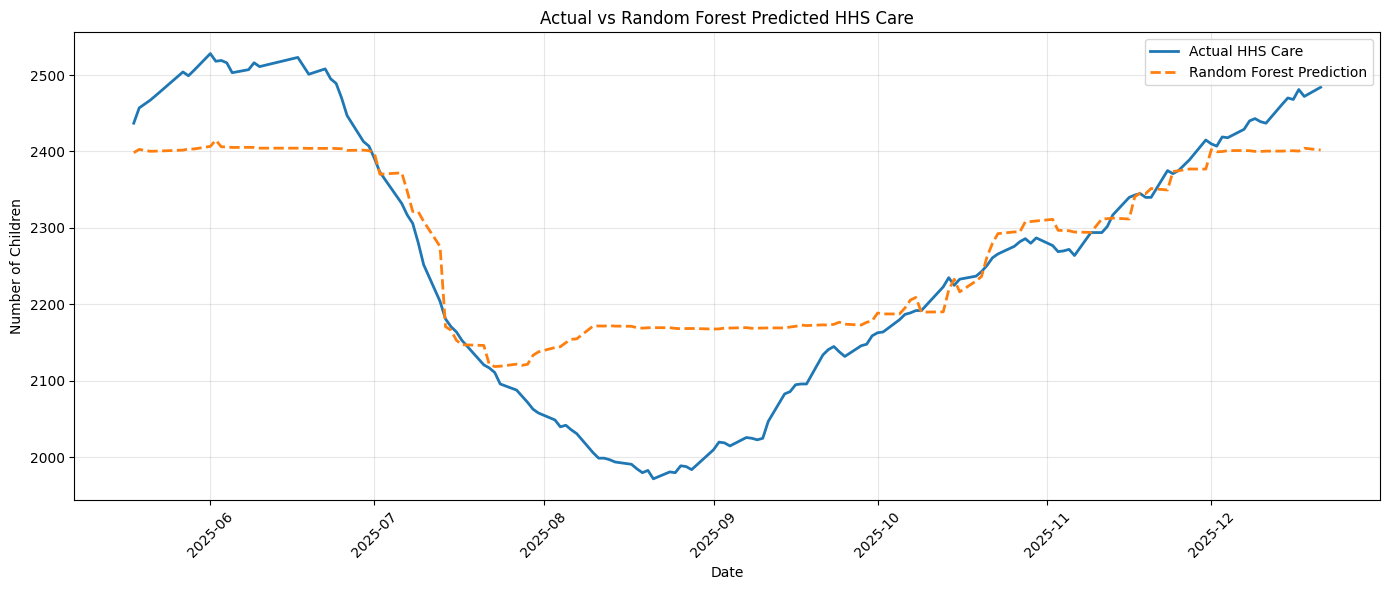

In [194]:
plt.figure(figsize=(14, 6))

plt.plot(
    ml_df["Date"].iloc[split_point_ml:],
    y_test.values,
    label="Actual HHS Care",
    linewidth=2
)

plt.plot(
    ml_df["Date"].iloc[split_point_ml:],
    rf_forecast,
    label="Random Forest Prediction",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Random Forest Predicted HHS Care")
plt.xlabel("Date")
plt.ylabel("Number of Children")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [195]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

           Feature  Importance
0            lag_1    0.836684
3   rolling_7_mean    0.103030
1            lag_7    0.028134
4  rolling_14_mean    0.022910
2           lag_14    0.006394
8            month    0.001121
7      day_of_week    0.000609
6   rolling_14_std    0.000539
5    rolling_7_std    0.000504
9             year    0.000075


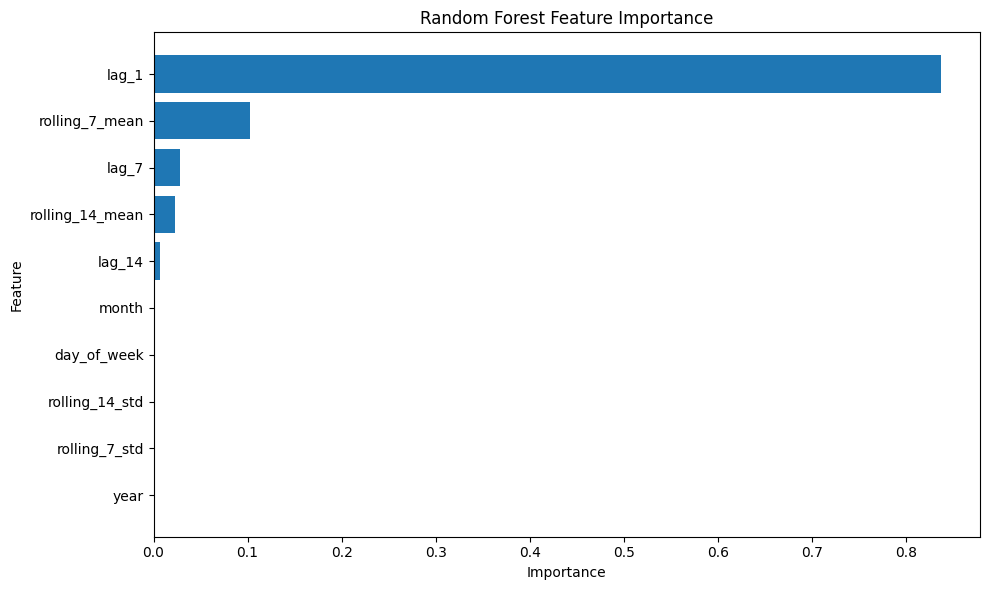

In [196]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()